In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/itc-nse-24-year-stock-data/ITC-EQ-01-04-2000-to-31-03-2024.csv


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/itc-nse-24-year-stock-data/ITC-EQ-01-04-2000-to-31-03-2024.csv')
df.head()

,date,series,open,high,low,prev._close,ltp,close,vwap,52w_h,52w_l,volume,value,no_of_trades
0,2000-04-03,EQ,739.9,800.8,721.05,741.45,792.75,797.00,772.76,1140.8,580.0,1720025,1.329165e+09,NaN
1,2000-04-04,EQ,785.0,785.0,733.25,797.00,733.25,733.25,744.37,1140.8,580.0,581309,4.327067e+08,NaN
2,2000-04-05,EQ,680.0,740.0,675.05,733.25,696.10,698.75,700.53,1140.8,580.0,706269,4.947637e+08,NaN
3,2000-04-06,EQ,705.0,711.0,646.10,698.75,685.00,682.80,676.06,1140.8,580.0,431386,2.916423e+08,NaN
4,2000-04-07,EQ,682.0,733.9,682.00,682.80,730.00,730.95,722.23,1140.8,580.0,1087357,7.853181e+08,NaN


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5981 entries, 0 to 5980
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          5981 non-null   object 
 1   series        5981 non-null   object 
 2   open          5981 non-null   float64
 3   high          5981 non-null   float64
 4   low           5981 non-null   float64
 5   prev._close   5981 non-null   float64
 6   ltp           5981 non-null   float64
 7   close         5981 non-null   float64
 8   vwap          5981 non-null   float64
 9   52w_h         5965 non-null   float64
 10  52w_l         5965 non-null   float64
 11  volume        5981 non-null   int64  
 12  value         5981 non-null   float64
 13  no_of_trades  3193 non-null   float64
dtypes: float64(11), int64(1), object(2)
memory usage: 654.3+ KB


In [4]:
# Convert 'Date' column to datetime type
df['date'] = pd.to_datetime(df['date'])

In [5]:
# Summary statistics
df.describe()

,date,open,high,low,prev._close,ltp,close,vwap,52w_h,52w_l,volume,value,no_of_trades
count,5981,5981.000000,5981.000000,5981.000000,5981.000000,5981.000000,5981.000000,5981.000000,5965.000000,5965.00000,5.981000e+03,5.981000e+03,3193.000000
mean,2012-03-26 04:38:48.172546304,405.041264,410.474962,399.325606,404.865491,404.783214,404.806629,404.971563,554.709388,295.90451,8.436510e+06,2.218858e+09,108612.629502
min,2000-04-03 00:00:00,115.000000,116.200000,114.400000,115.450000,115.500000,115.450000,115.390000,194.800000,114.40000,6.797000e+03,5.340132e+06,1425.000000
25%,2006-03-16 00:00:00,206.400000,208.400000,203.850000,206.050000,206.200000,206.250000,205.970000,271.000000,151.55000,2.286848e+06,6.435492e+08,63041.000000
50%,2012-03-22 00:00:00,281.850000,284.000000,278.500000,281.550000,281.500000,281.550000,281.330000,367.700000,222.00000,5.974804e+06,1.490216e+09,93699.000000
75%,2018-04-10 00:00:00,443.400000,446.850000,439.700000,442.900000,443.100000,442.900000,443.040000,782.650000,323.25000,1.022830e+07,2.861615e+09,132996.000000
max,2024-03-28 00:00:00,1946.000000,1964.800000,1916.300000,1940.100000,1940.000000,1940.100000,1933.790000,1964.800000,1059.90000,1.494797e+08,4.347518e+10,734612.000000
std,NaN,309.513335,314.165692,305.155939,309.616921,309.525200,309.590639,309.764341,450.850561,192.27517,1.063934e+07,2.644908e+09,68787.567612


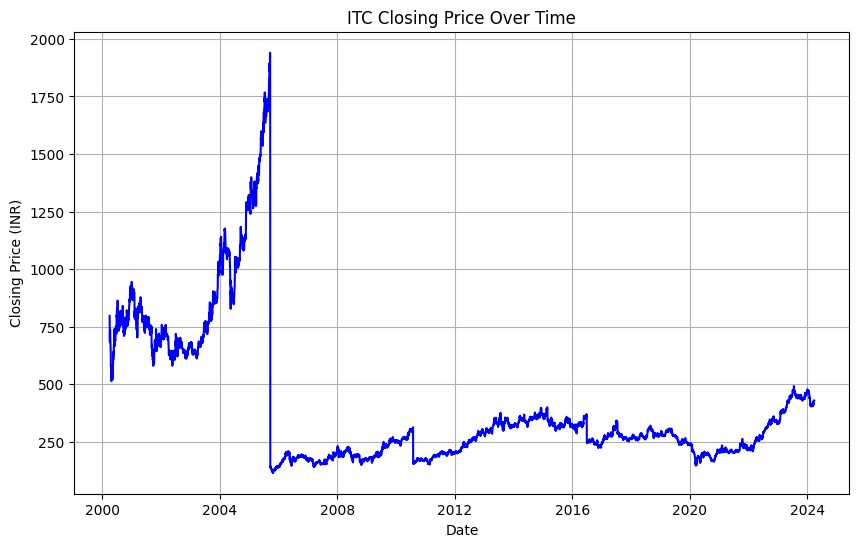

In [6]:
# Plot closing price over time
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['close'], color='blue')
plt.title('ITC Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.grid(True)
plt.show()

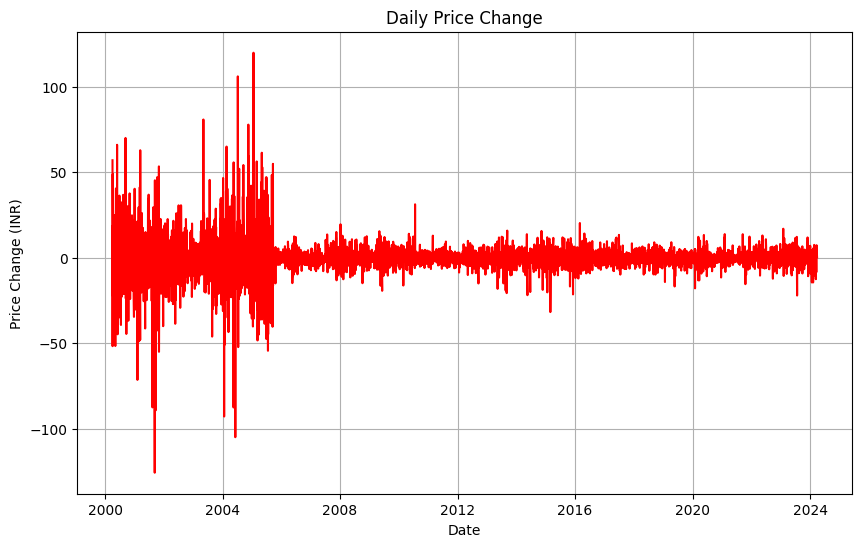

In [7]:
# Calculate and plot daily price change
df['Price_Change'] = df['close'] - df['open']
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['Price_Change'], color='red')
plt.title('Daily Price Change')
plt.xlabel('Date')
plt.ylabel('Price Change (INR)')
plt.grid(True)
plt.show()

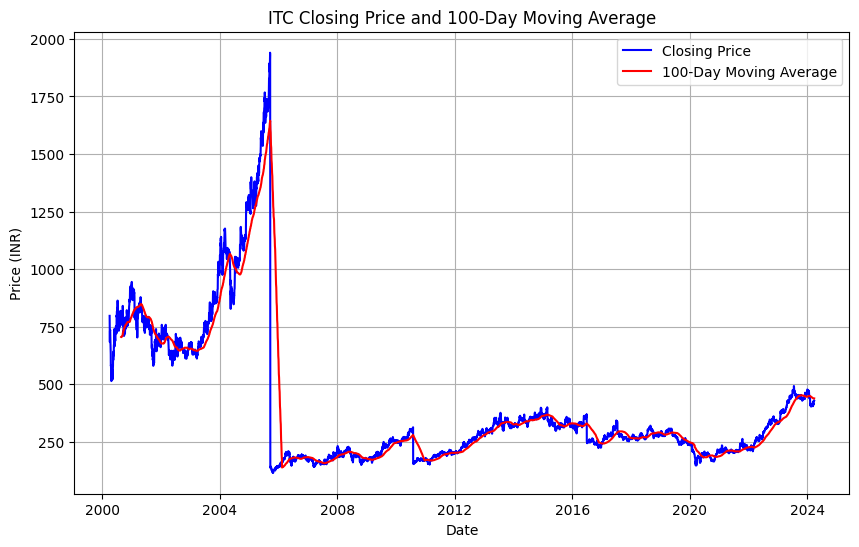

In [8]:
# Calculate and plot moving average
window = 100
df['MA'] = df['close'].rolling(window=window).mean()
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['close'], label='Closing Price', color='blue')
plt.plot(df['date'], df['MA'], label=f'{window}-Day Moving Average', color='red')
plt.title(f'ITC Closing Price and {window}-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

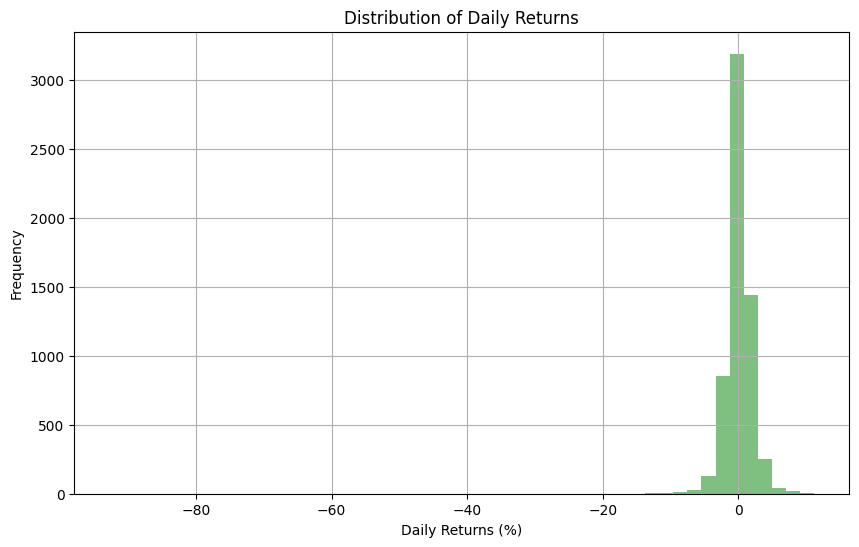

In [9]:
# Calculate daily returns
df['Daily_Returns'] = df['close'].pct_change() * 100

# Plot distribution of daily returns
plt.figure(figsize=(10, 6))
plt.hist(df['Daily_Returns'].dropna(), bins=50, color='green', alpha=0.5)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

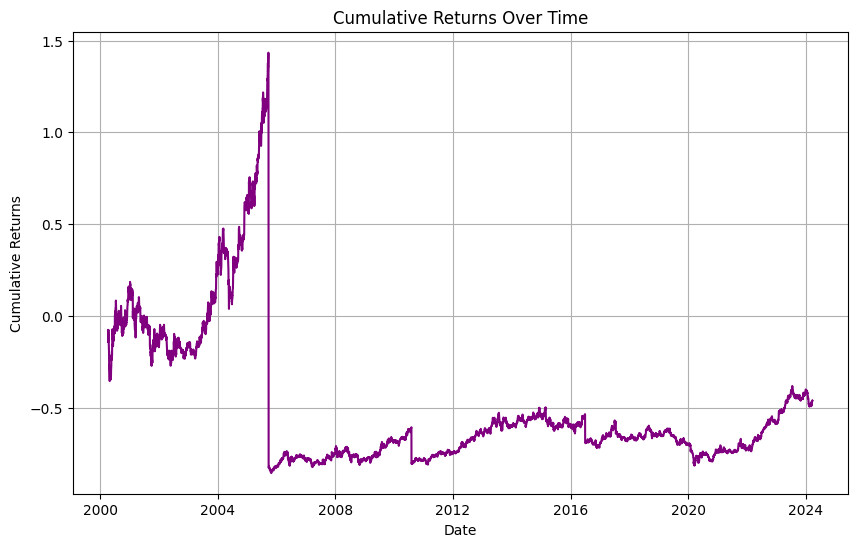

In [10]:
# Calculate cumulative returns
df['Cumulative_Returns'] = (1 + df['Daily_Returns'] / 100).cumprod() - 1

# Plot cumulative returns
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['Cumulative_Returns'], color='purple')
plt.title('Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True)
plt.show()

In [11]:
# Identify maximum drawdown
df['Roll_Max'] = df['close'].cummax()
df['Drawdown'] = df['close'] / df['Roll_Max'] - 1
max_drawdown = df['Drawdown'].min()

# Print maximum drawdown
print(f'Maximum Drawdown: {max_drawdown:.2%}')

Maximum Drawdown: -94.05%


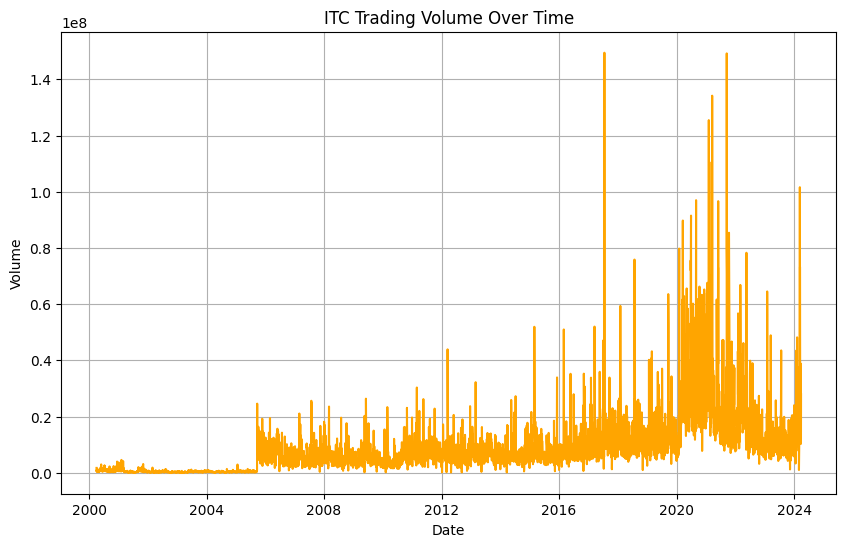

In [12]:
# Calculate and plot trading volume over time
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['volume'], color='orange')
plt.title('ITC Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

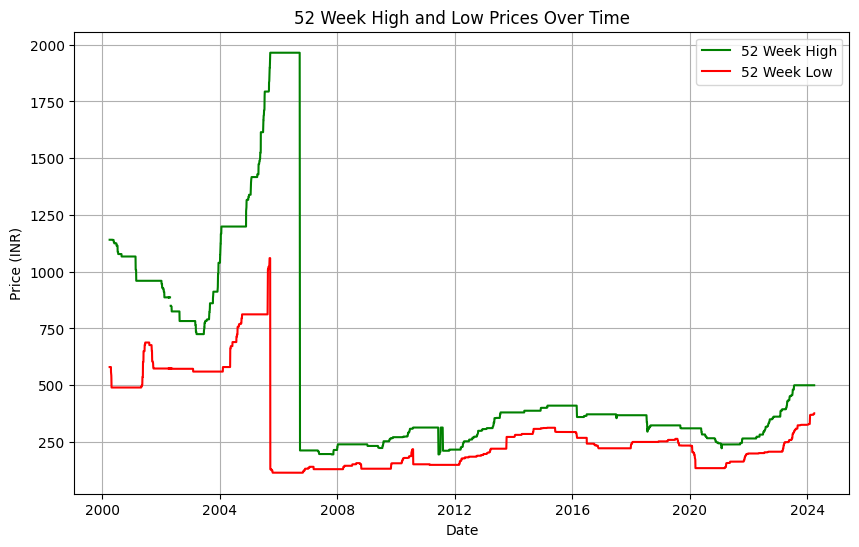

In [13]:
# Calculate and plot 52-week high and low prices over time
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['52w_h'], label='52 Week High', color='green')
plt.plot(df['date'], df['52w_l'], label='52 Week Low', color='red')
plt.title('52 Week High and Low Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

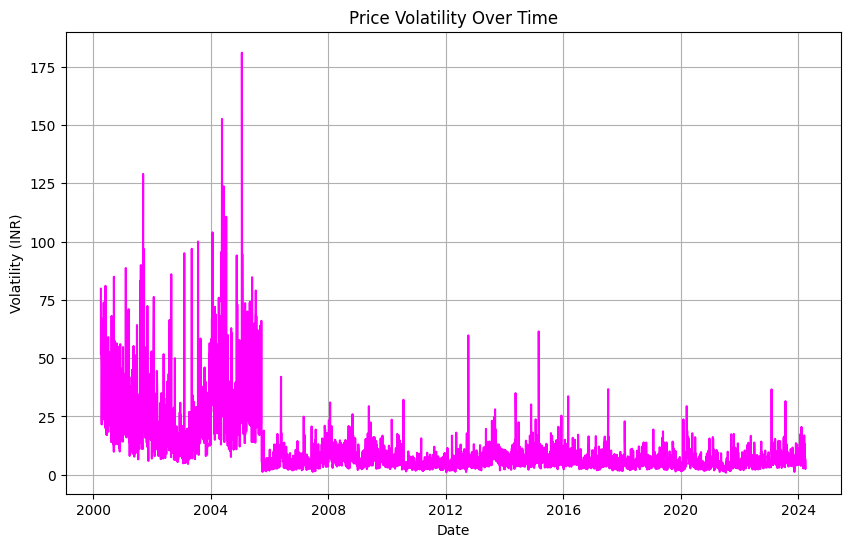

In [14]:
# Calculate and plot price volatility (High - Low) over time
df['Volatility'] = df['high'] - df['low']
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['Volatility'], color='magenta')
plt.title('Price Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (INR)')
plt.grid(True)
plt.show()

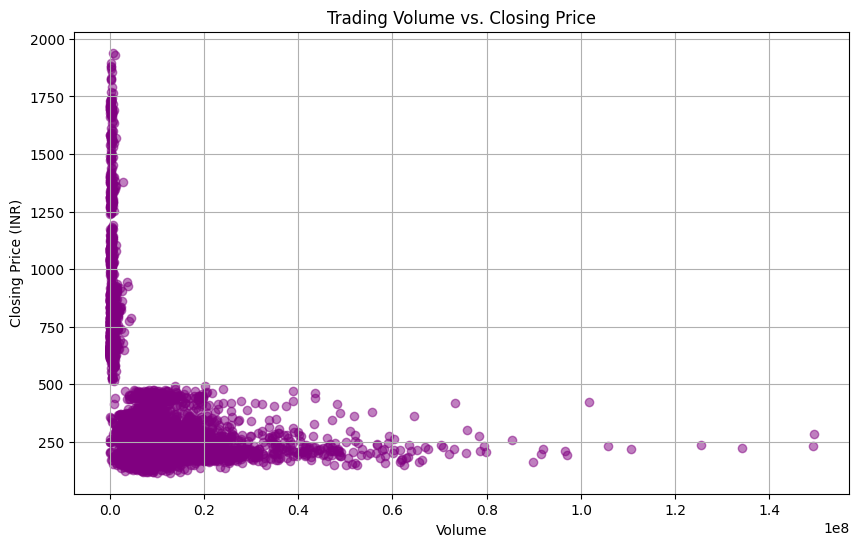

In [15]:
# Calculate and plot trading volume and closing price relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['volume'], df['close'], color='purple', alpha=0.5)
plt.title('Trading Volume vs. Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price (INR)')
plt.grid(True)
plt.show()

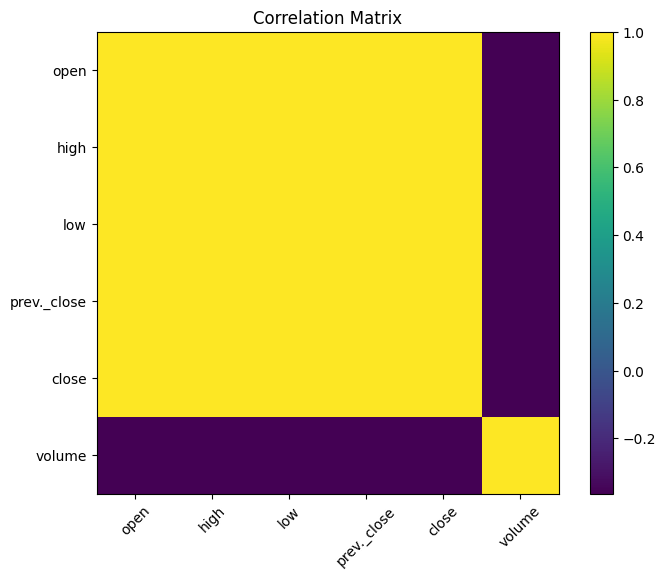

In [16]:
# Calculate and plot correlation matrix
correlation_matrix = df[['open', 'high', 'low', 'prev._close', 'close', 'volume']].corr()
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix,  interpolation='nearest')
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.show()